## 1. Setup and Path Configuration

In [ ]:
import json
import cv2
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from pycocotools import mask as mask_utils

# ================= CONFIGURAÇÃO DE CAMINHOS =================
unb_server = True

if unb_server:
    LOCAL_PATH = "/home/antoniovinicius/projects/sandbox_sam3"
else:
    LOCAL_PATH = "/home/avmoura_linux/Documents/unb/sandbox_sam3"

# Dicionário consolidando todos os experimentos
EXPERIMENTS = {
    "ISIC ATT": {
        "log_dir": Path(f"{LOCAL_PATH}/logs/isic_train_seg"),
        "images_dir": Path(f"{LOCAL_PATH}/datasets/isic_att_dataset/valid/"),
        "pred_json": Path(f"{LOCAL_PATH}/logs/isic_train_seg/dumps/isic/coco_predictions_segm.json"),
        "gt_json": Path(f"{LOCAL_PATH}/datasets/isic_att_dataset/valid/_annotations.coco.json"),
    },
    "PH2": {
        "log_dir": Path(f"{LOCAL_PATH}/logs/ph2_train_seg_500_3"),
        "images_dir": Path(f"{LOCAL_PATH}/datasets/ph2_dataset/test/"),
        "pred_json": Path(f"{LOCAL_PATH}/logs/ph2_train_seg_500_3/dumps/ph2/coco_predictions_segm.json"),
        "gt_json": Path(f"{LOCAL_PATH}/datasets/ph2_dataset/test/_annotations.coco.json"),
    },
    "ISIC 10k": {
        "log_dir": Path(f"{LOCAL_PATH}/logs/isic_10k_train_seg_500"),
        "images_dir": Path(f"{LOCAL_PATH}/datasets/isic_10k_dataset/valid/"),
        "pred_json": Path(f"{LOCAL_PATH}/logs/isic_10k_train_seg_500/dumps/isic_10k/coco_predictions_segm.json"),
        "gt_json": Path(f"{LOCAL_PATH}/datasets/isic_10k_dataset/valid/_annotations.coco.json"),
    }
}

SCORE_THRESHOLD = 0.35
MASK_ALPHA = 0.45
OVERLAY_MASKS = True

## 2. Gráfico Comparativo de AP

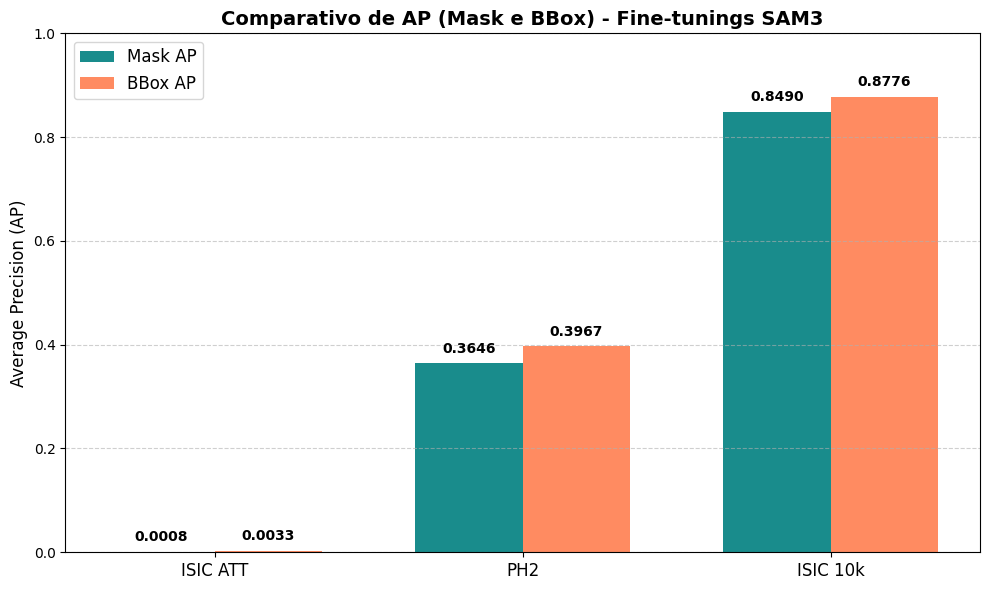

In [9]:
def load_stats(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        return pd.DataFrame()
    
    data = []
    with open(json_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(data)

summary_metrics = {}

# Puxando a última época de validação de cada modelo
for exp_name, config in EXPERIMENTS.items():
    df_val = load_stats(config["log_dir"] / "val_stats.json")
    if not df_val.empty:
        last_epoch = df_val.iloc[-1]
        
        segm_ap, bbox_ap = None, None
        for col, val in last_epoch.items():
            if "coco_eval_segm_AP" in col and pd.notna(val) and val != -1.0:
                segm_ap = val
            elif "coco_eval_bbox_AP" in col and pd.notna(val) and val != -1.0:
                bbox_ap = val
                
        summary_metrics[exp_name] = {"Mask AP": segm_ap, "BBox AP": bbox_ap}

df_summary = pd.DataFrame(summary_metrics).T

# Plotando o gráfico resumo
plt.figure(figsize=(10, 6))
x = np.arange(len(df_summary))
width = 0.35

plt.bar(x - width/2, df_summary['Mask AP'], width, label='Mask AP', color='teal', alpha=0.9)
plt.bar(x + width/2, df_summary['BBox AP'], width, label='BBox AP', color='coral', alpha=0.9)

plt.ylabel('Average Precision (AP)', fontsize=12)
plt.title('Comparativo de AP (Mask e BBox) - Fine-tunings SAM3', fontsize=14, fontweight='bold')
plt.xticks(x, df_summary.index, fontsize=12)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionando os valores em cima de cada barra
for i, v in enumerate(df_summary['Mask AP']):
    if pd.notna(v):
        plt.text(i - width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', color='black')
for i, v in enumerate(df_summary['BBox AP']):
    if pd.notna(v):
        plt.text(i + width/2, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

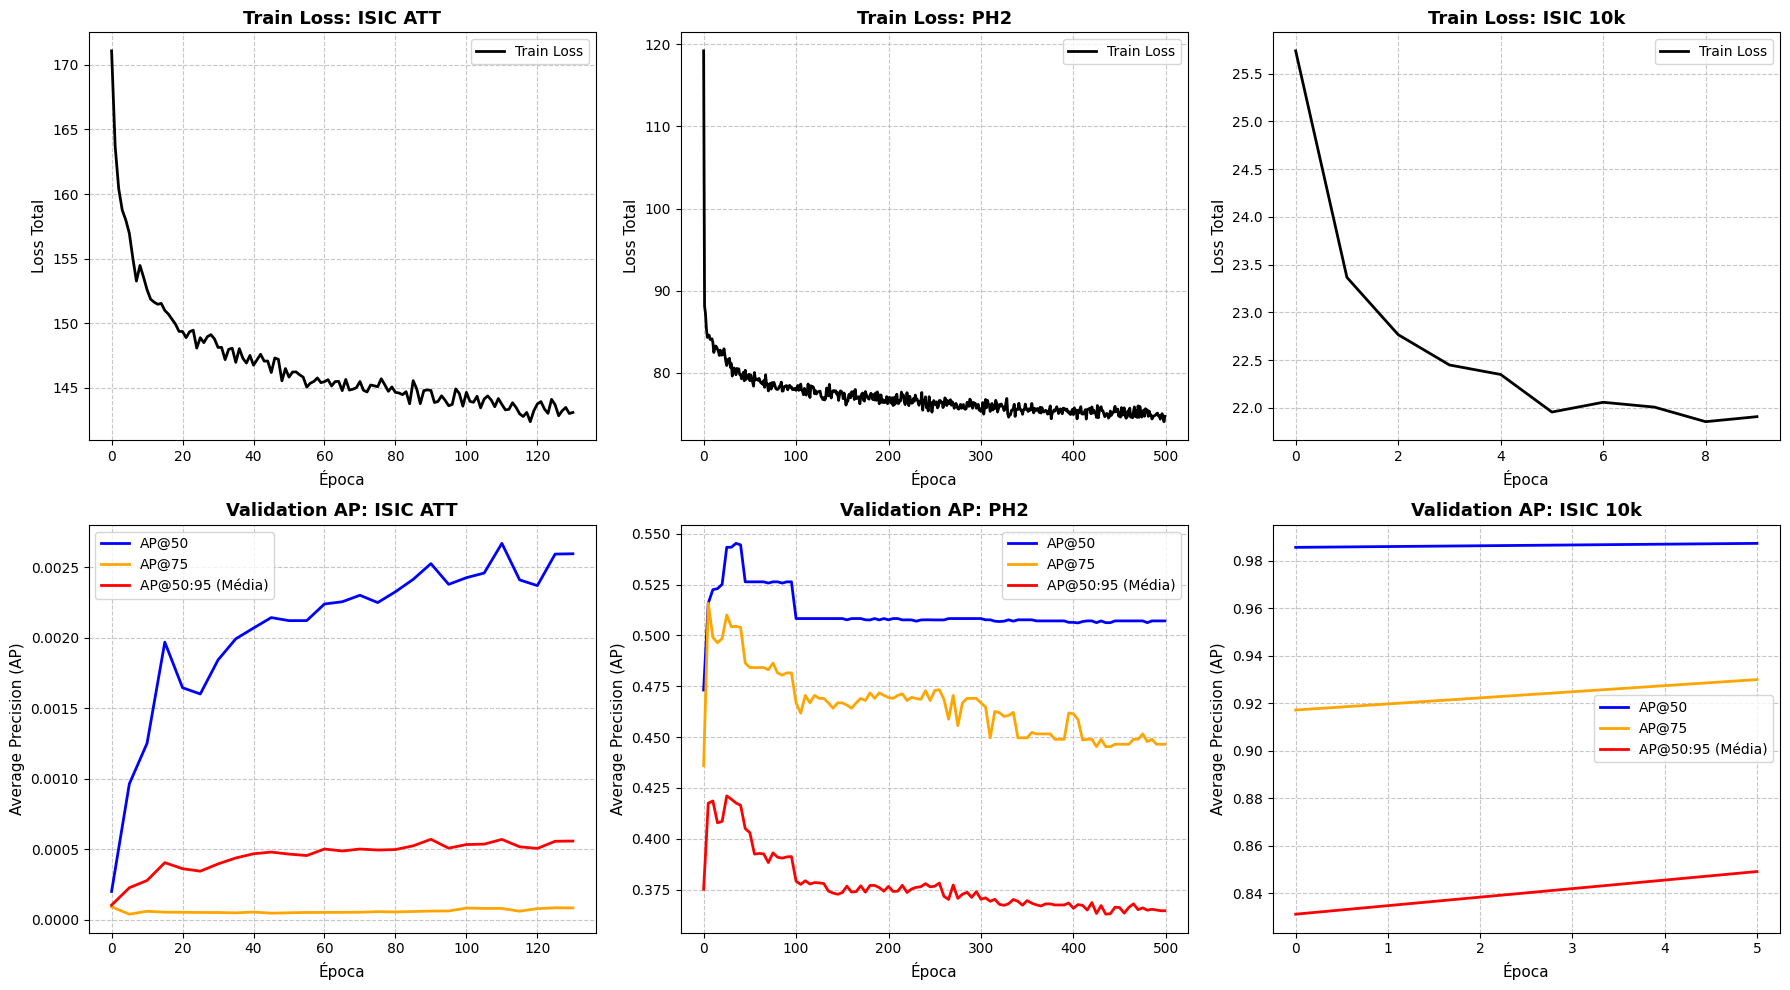

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (exp_name, config) in enumerate(EXPERIMENTS.items()):
    df_train = load_stats(config["log_dir"] / "train_stats.json")
    df_val = load_stats(config["log_dir"] / "val_stats.json")
    
    ax_loss = axes[0, idx]
    ax_ap = axes[1, idx]
    
    # ==========================
    # 1. Gráfico de Loss (Cima)
    # ==========================
    if not df_train.empty and 'Trainer/epoch' in df_train.columns and 'Losses/train_all_loss' in df_train.columns:
        ax_loss.plot(df_train['Trainer/epoch'], df_train['Losses/train_all_loss'], color='black', linewidth=2, label='Train Loss')
        ax_loss.set_title(f'Train Loss: {exp_name}', fontsize=13, fontweight='bold')
        ax_loss.set_xlabel('Época', fontsize=11)
        ax_loss.set_ylabel('Loss Total', fontsize=11)
        ax_loss.legend(fontsize=10)
        ax_loss.grid(True, linestyle='--', alpha=0.7)
    else:
        ax_loss.set_title(f'{exp_name} - Dados de Loss não encontrados')
        ax_loss.axis('off')
        
    # ==========================
    # 2. Gráfico de AP (Baixo)
    # ==========================
    if not df_val.empty and 'Trainer/epoch' in df_val.columns:
        epoch_col = 'Trainer/epoch'
        
        # Buscando colunas dinamicamente
        ap_50_col = next((c for c in df_val.columns if c.endswith('coco_eval_segm_AP_50')), None)
        ap_75_col = next((c for c in df_val.columns if c.endswith('coco_eval_segm_AP_75')), None)
        ap_col    = next((c for c in df_val.columns if c.endswith('coco_eval_segm_AP') and 'AP_' not in c[-5:]), None)
        
        if ap_50_col and ap_50_col in df_val.columns:
            ax_ap.plot(df_val[epoch_col], df_val[ap_50_col], label='AP@50', color='blue', linewidth=2)
        if ap_75_col and ap_75_col in df_val.columns:
            ax_ap.plot(df_val[epoch_col], df_val[ap_75_col], label='AP@75', color='orange', linewidth=2)
        if ap_col and ap_col in df_val.columns:
            ax_ap.plot(df_val[epoch_col], df_val[ap_col], label='AP@50:95 (Média)', color='red', linewidth=2)

        ax_ap.set_title(f'Validation AP: {exp_name}', fontsize=13, fontweight='bold')
        ax_ap.set_xlabel('Época', fontsize=11)
        ax_ap.set_ylabel('Average Precision (AP)', fontsize=11)
        ax_ap.legend(fontsize=10)
        ax_ap.grid(True, linestyle='--', alpha=0.7)
    else:
        ax_ap.set_title(f'{exp_name} - Dados de Validação não encontrados')
        ax_ap.axis('off')

plt.tight_layout()
plt.show()

## 3. Funções de Visualização

In [3]:
def load_json_data(pred_path: Path, gt_path: Path) -> Tuple[Dict[int, List[Dict]], Dict[int, List[Dict]], Dict[int, str]]:
    preds_map, gt_map, id_to_filename = {}, {}, {}
    
    if pred_path.exists():
        with open(pred_path, 'r') as f:
            preds = json.load(f)
        for p in preds:
            preds_map.setdefault(p['image_id'], []).append(p)

    if gt_path.exists():
        with open(gt_path, 'r') as f:
            gt = json.load(f)
        for img in gt['images']:
            id_to_filename[img['id']] = img['file_name']
        for ann in gt.get('annotations', []):
            gt_map.setdefault(ann['image_id'], []).append(ann)
            
    return preds_map, gt_map, id_to_filename

def apply_mask(image: np.ndarray, mask: np.ndarray, color: List[int], alpha: float):
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                  image[:, :, c] * (1 - alpha) + alpha * color[c],
                                  image[:, :, c])
    return image

def draw_visualizations(img: np.ndarray, annotations: List[Dict], threshold: float = 0.0, is_gt: bool = False, color_override: List[int] = None) -> Tuple[int, np.ndarray]:
    count = 0
    img_h, img_w = img.shape[:2]
    
    if not is_gt:
        annotations.sort(key=lambda x: x.get('score', 0)) 

    for ann in annotations:
        score = ann.get('score', 1.0)
        if not is_gt and score < threshold: 
            continue

        if color_override:
            color = color_override
        else:
            color = [0, 255, 0] if is_gt else [random.randint(50, 255) for _ in range(3)]
        
        # Máscara
        if 'segmentation' in ann:
            try:
                segm = ann['segmentation']
                binary_mask = np.zeros((img_h, img_w), dtype=np.uint8)
                
                if isinstance(segm, list):
                    for poly in segm:
                        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                        cv2.fillPoly(binary_mask, [pts], 1)
                
                elif isinstance(segm, dict):
                    binary_mask = mask_utils.decode(segm)
                    if binary_mask.shape[:2] != (img_h, img_w):
                        binary_mask = cv2.resize(binary_mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

                img = apply_mask(img, binary_mask, color, MASK_ALPHA)
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(img, contours, -1, (255, 255, 255), 1)
            except Exception as e:
                pass

        # Bounding Box
        if 'bbox' in ann:
            bbox = ann['bbox']
            if all(v <= 1.1 for v in bbox):
                x, y, w, h = int(bbox[0]*img_w), int(bbox[1]*img_h), int(bbox[2]*img_w), int(bbox[3]*img_h)
            else:
                x, y, w, h = map(int, bbox)
                
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            
            # Text Label
            if not is_gt:
                label = f"Pred: {score:.2f}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x, y - 20), (x + tw, y), color, -1)
                cv2.putText(img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            else:
                label = "GT"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                offset_x = x + 80 if OVERLAY_MASKS else x
                cv2.rectangle(img, (offset_x, y - 20), (offset_x + tw, y), color, -1)
                cv2.putText(img, label, (offset_x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
                
        count += 1
        
    return count, img

## 4. Resultados Qualitativos (Dermatologista vs SAM3)


🌟 Visualizações Qualitativas: ISIC ATT 🌟


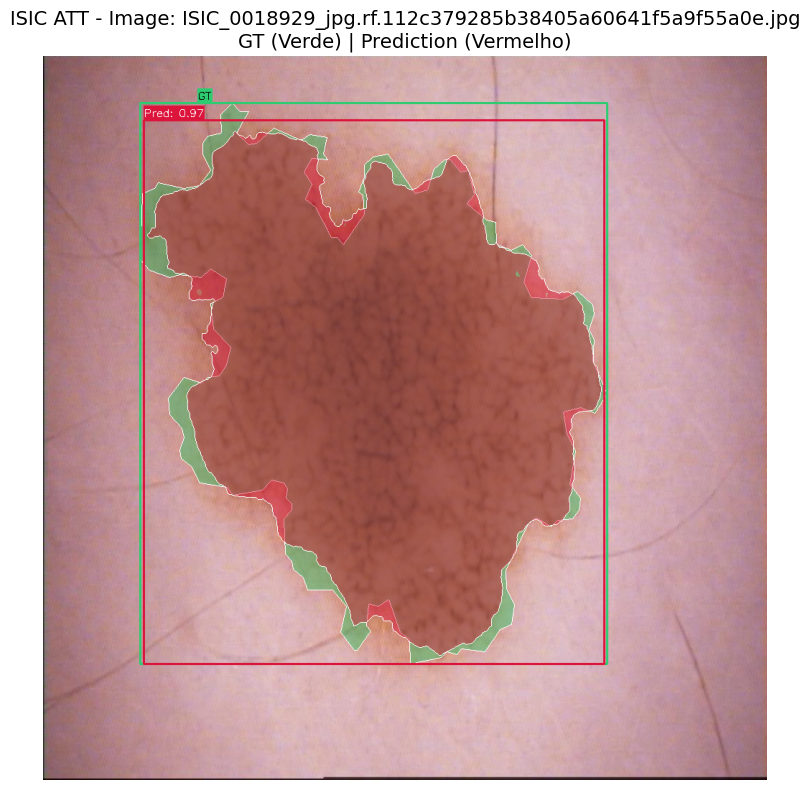

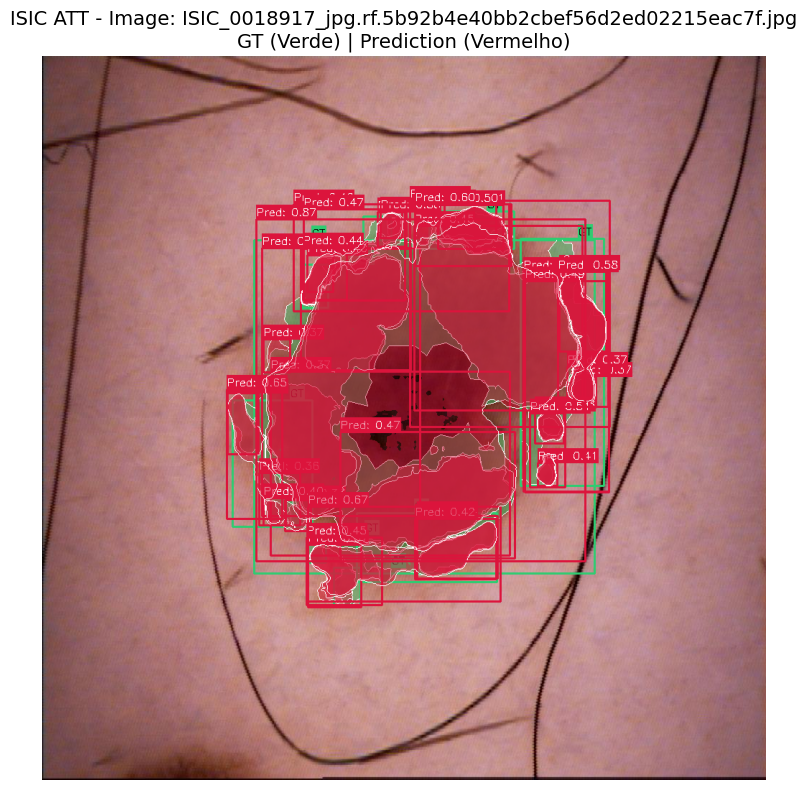

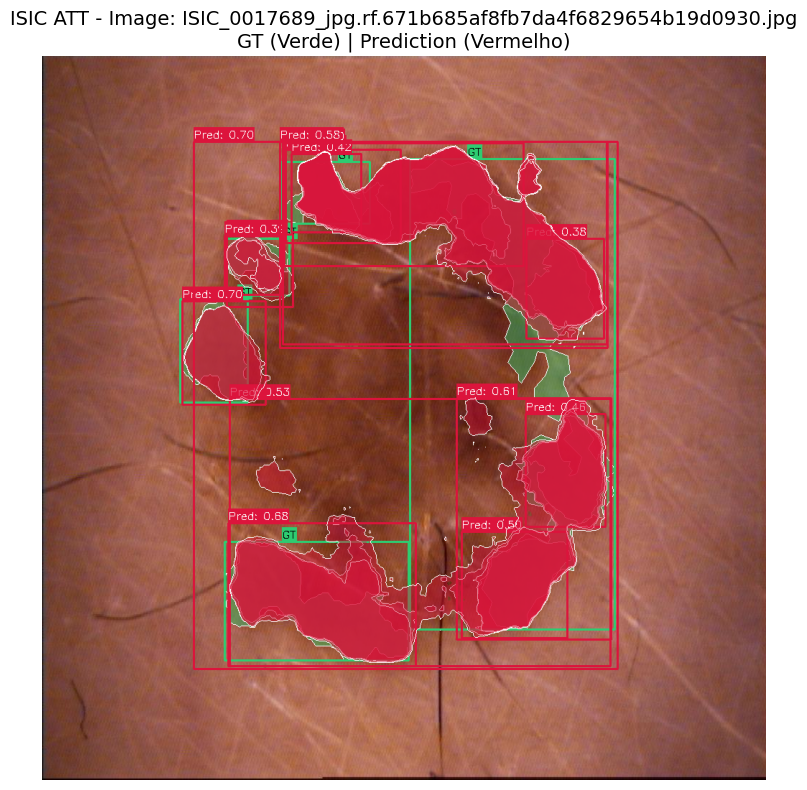


🌟 Visualizações Qualitativas: PH2 🌟


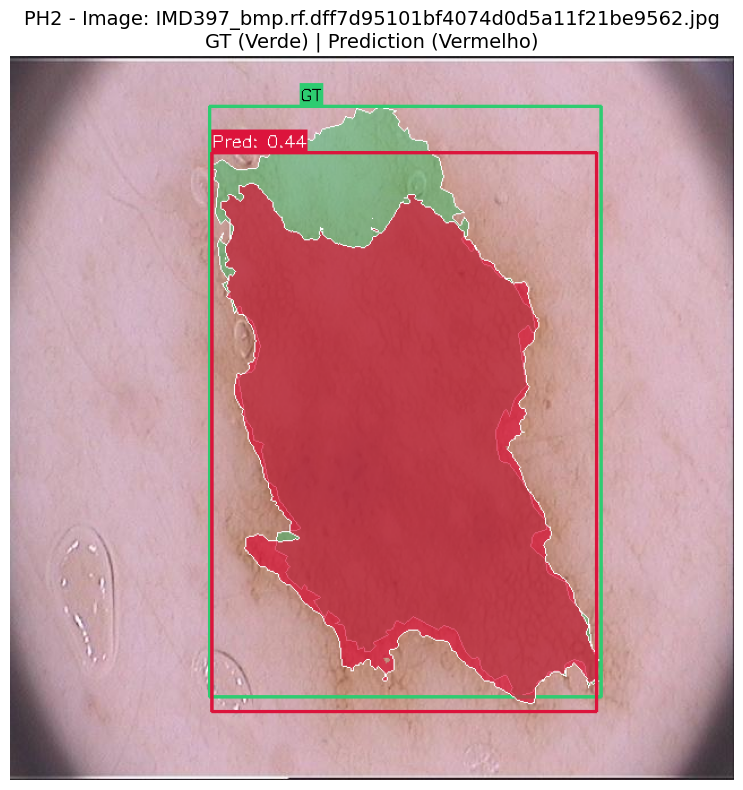

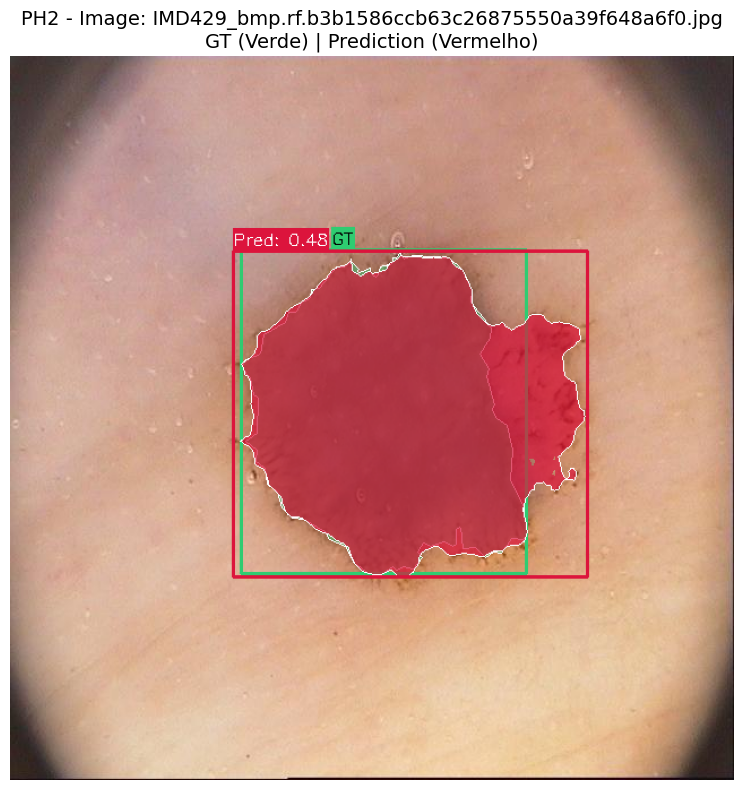

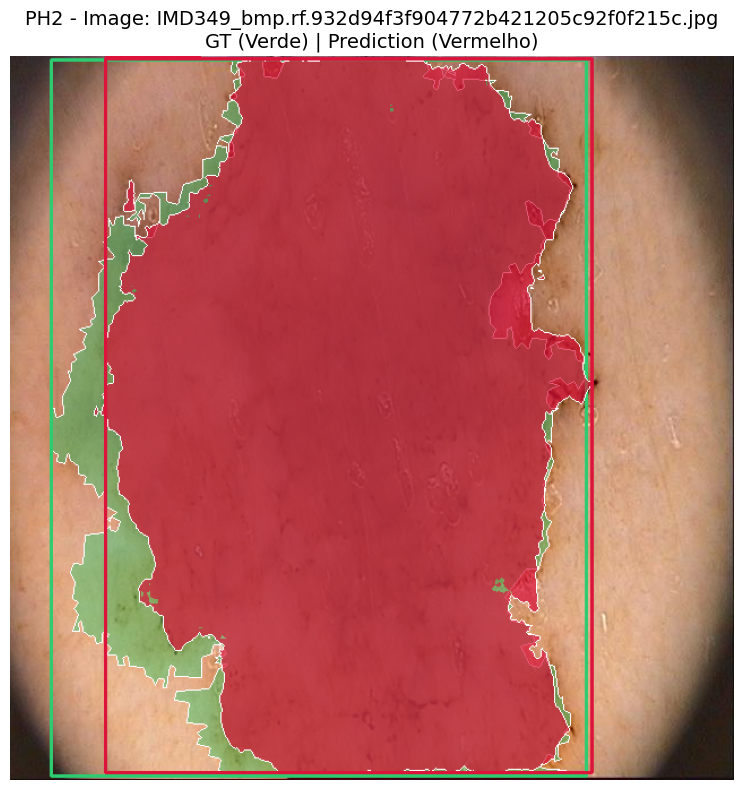


🌟 Visualizações Qualitativas: ISIC 10k 🌟


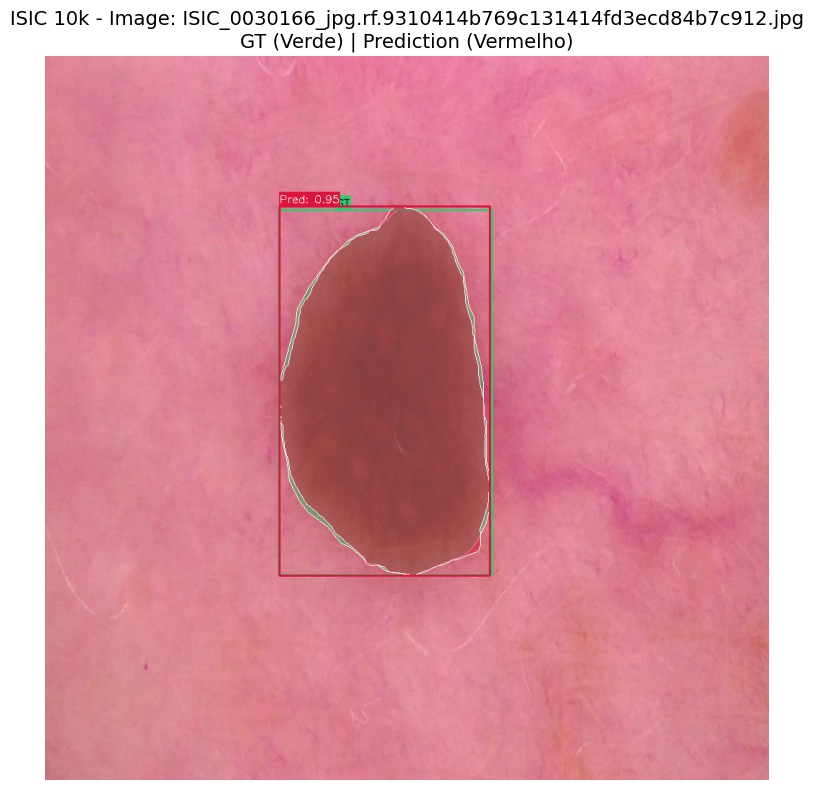

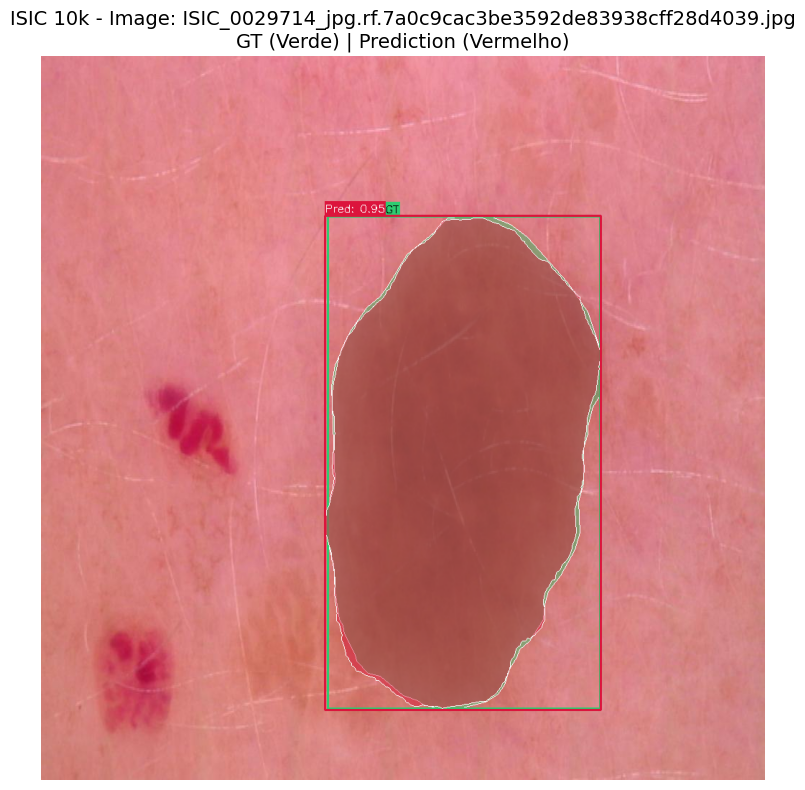

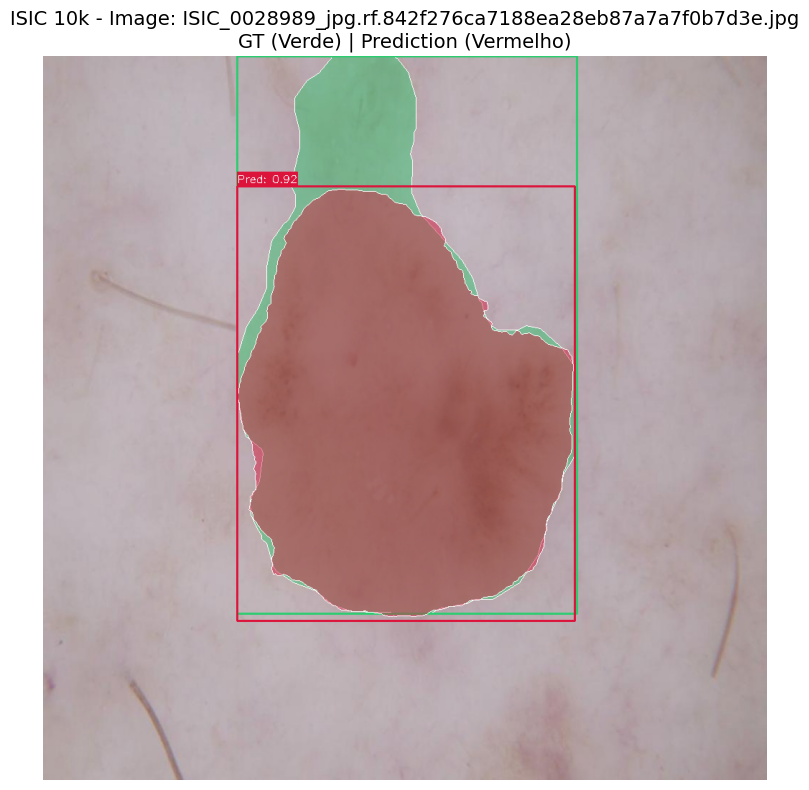

In [4]:
NUM_IMAGES_TO_SHOW = 3 # Quantas imagens exibir por experimento (ajuste como quiser)

for exp_name, config in EXPERIMENTS.items():
    print("\n" + "="*70)
    print(f"🌟 Visualizações Qualitativas: {exp_name} 🌟")
    print("="*70)
    
    preds_map, gt_map, id_to_filename = load_json_data(config["pred_json"], config["gt_json"])
    shown = 0
    
    for img_id, predictions in preds_map.items():
        if shown >= NUM_IMAGES_TO_SHOW:
            break
            
        if id_to_filename and img_id in id_to_filename:
            img_path = config["images_dir"] / id_to_filename[img_id]
            if not img_path.exists():
                continue
                
            original_img = cv2.imread(str(img_path))
            if original_img is None:
                continue
                
            gt_annotations = gt_map.get(img_id, [])
            
            if OVERLAY_MASKS:
                combined_img = original_img.copy()
                
                # 1. Ground Truth (Verde: [113, 204, 46])
                gt_count, combined_img = draw_visualizations(combined_img, gt_annotations, is_gt=True, color_override=[113, 204, 46])
                
                # 2. Previsões do Modelo (Vermelho: [60, 20, 220] BGR no OpenCV)
                pred_count, combined_img = draw_visualizations(combined_img, predictions, SCORE_THRESHOLD, is_gt=False, color_override=[60, 20, 220])
                
                if pred_count > 0 or gt_count > 0:
                    combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
                    
                    plt.figure(figsize=(8, 8))
                    plt.imshow(combined_img_rgb)
                    plt.title(f"{exp_name} - Image: {id_to_filename[img_id]}\nGT (Verde) | Prediction (Vermelho)", fontsize=14)
                    plt.axis('off')
                    plt.tight_layout()
                    plt.show()
                    shown += 1